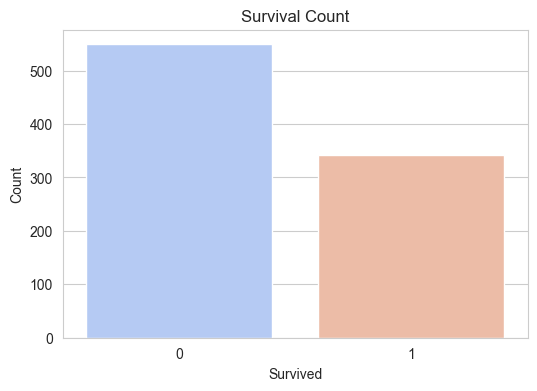

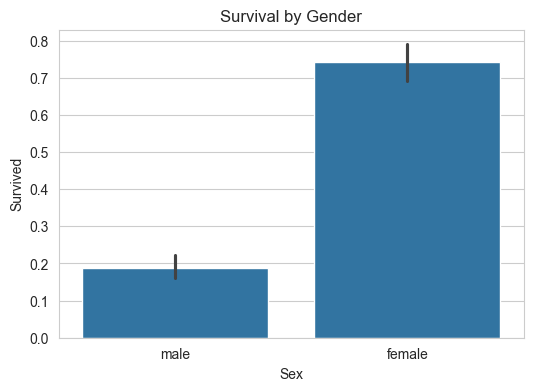

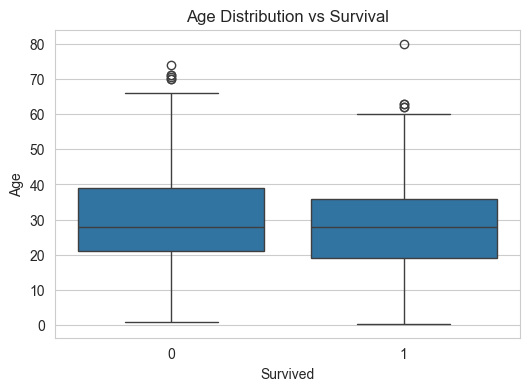

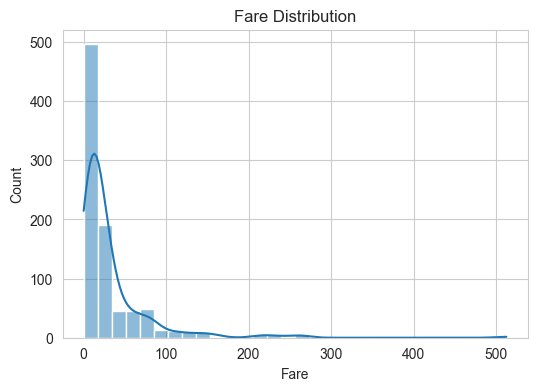

=== Logistic Regression ===
Accuracy: 0.8101
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179

=== Random Forest ===
Accuracy: 0.8156
              precision    recall  f1-score   support

           0       0.84      0.85      0.84       105
           1       0.78      0.77      0.78        74

    accuracy                           0.82       179
   macro avg       0.81      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179

=== SVM ===
Accuracy: 0.6592
              precision    recall  f1-score   support

           0       0.64      0.94      0.76       105
           1       0.76      0.26      0.38        74

    accuracy                           0.66       179
   macro avg   

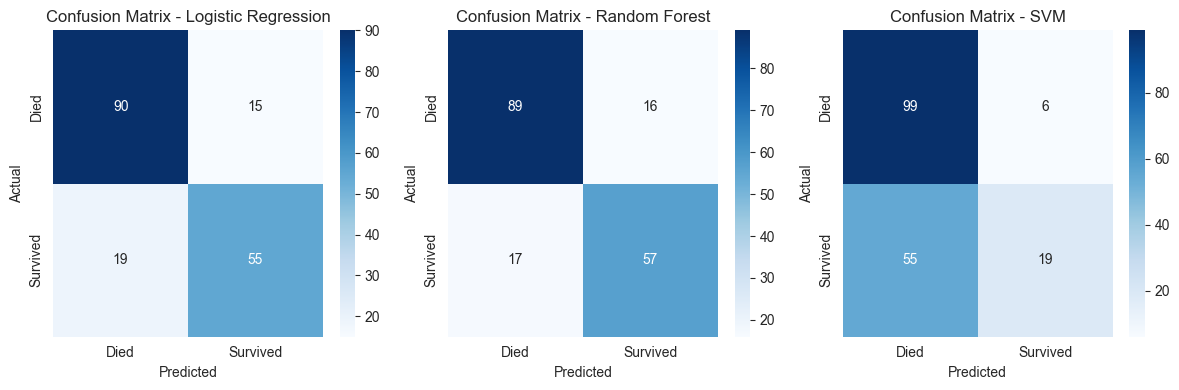

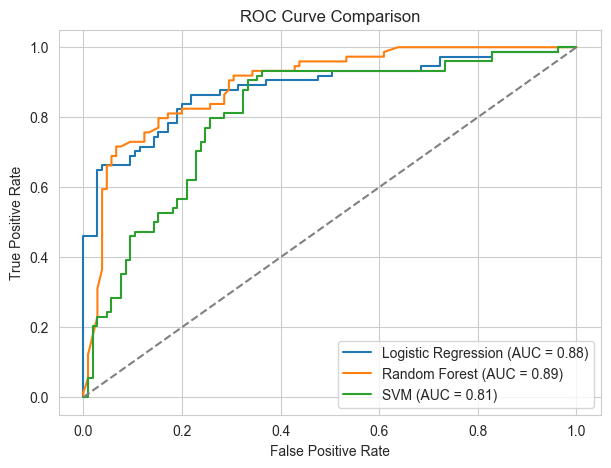


=== Cross-validation Accuracy (5-fold) ===
Logistic Regression: 0.7890 (+/- 0.0169)
Random Forest: 0.8047 (+/- 0.0250)
SVM: 0.6746 (+/- 0.0423)


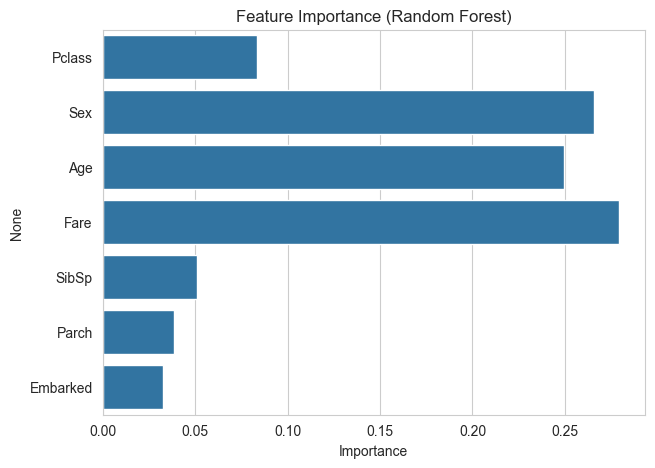

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, auc
)

sns.set_style("whitegrid")

# Load dataset
titanic = pd.read_csv("titanic.csv")

# Select features
features = ["Pclass", "Sex", "Age", "Fare", "SibSp", "Parch", "Embarked"]
X = titanic[features].copy()
y = titanic["Survived"]

# Encode categorical variables
X["Sex"] = LabelEncoder().fit_transform(X["Sex"])
X["Embarked"] = X["Embarked"].fillna("S")
X["Embarked"] = LabelEncoder().fit_transform(X["Embarked"])

# Handle missing values
imputer = SimpleImputer(strategy="median")
X[["Age", "Fare"]] = imputer.fit_transform(X[["Age", "Fare"]])

# ----
# EDA 
# ----
plt.figure(figsize=(6,4))

sns.countplot(x="Survived", data=titanic, hue="Survived", palette="coolwarm", legend=False)
plt.title("Survival Count")
plt.xlabel("Survived")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(6,4))
sns.barplot(x="Sex", y="Survived", data=titanic)
plt.title("Survival by Gender")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x="Survived", y="Age", data=titanic)
plt.title("Age Distribution vs Survival")
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(titanic["Fare"], bins=30, kde=True)
plt.title("Fare Distribution")
plt.show()

# ------------------
# Train-test split
# ------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Models to compare
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(kernel="rbf", probability=True, random_state=42)
}

# Train, evaluate, and visualize confusion matrices
plt.figure(figsize=(12,4))
for i, (name, model) in enumerate(models.items(), 1):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f"=== {name} ===")
    print("Accuracy:", round(acc, 4))
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    plt.subplot(1, 3, i)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Died", "Survived"],
                yticklabels=["Died", "Survived"])
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

plt.tight_layout()
plt.show()

# ROC-AUC Curve comparison (use predict_proba when available)
plt.figure(figsize=(7,5))
for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

# Cross-validation scores
print("\n=== Cross-validation Accuracy (5-fold) ===")
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5)
    print(f"{name}: {scores.mean():.4f} (+/- {scores.std():.4f})")

# Feature Importance (Random Forest)
rf = models["Random Forest"]
importances = rf.feature_importances_
feat_names = X.columns

plt.figure(figsize=(7,5))
sns.barplot(x=importances, y=feat_names)
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.show()
